In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [3]:
filenames = [0,2,3,4,5]

labels_str = ['DDoS', 'Benign', 'DoS', 'BruteForce', 'Bot', 'Web']

filenames

# pd.set_option('future.no_silent_downcasting', True)

[0, 2, 3, 4, 5]

0


Label
1    514148
2    329224
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


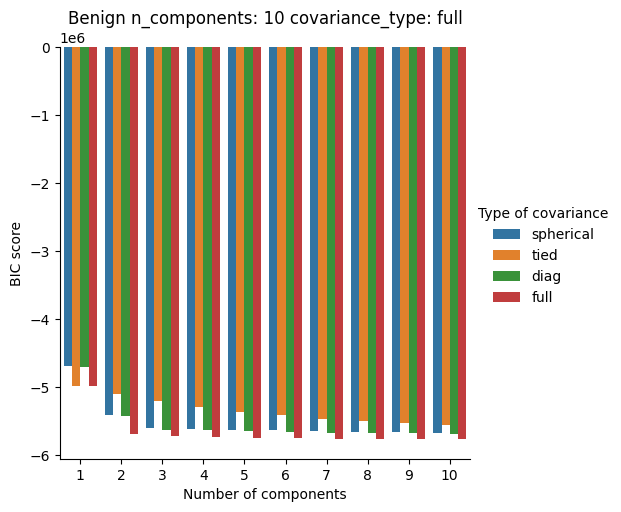

Tipo: 2 = DoS
Melhor modelo: n_componentes: 9 covariance_type: full


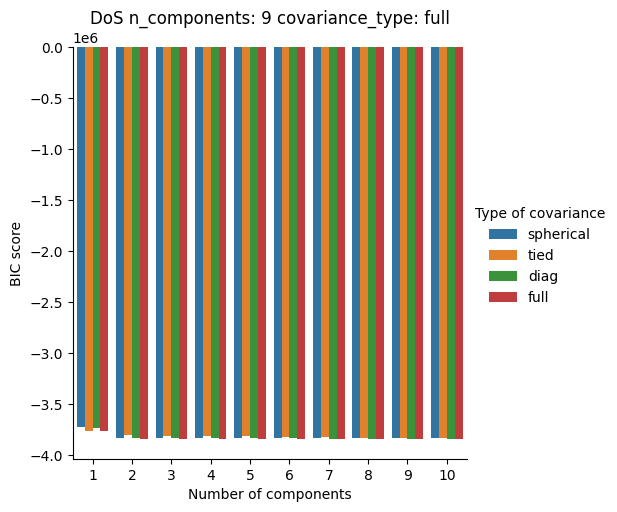

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 3 covariance_type: full


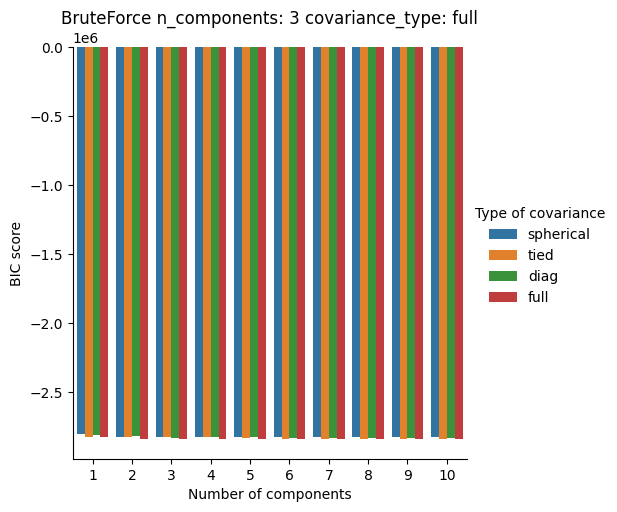

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


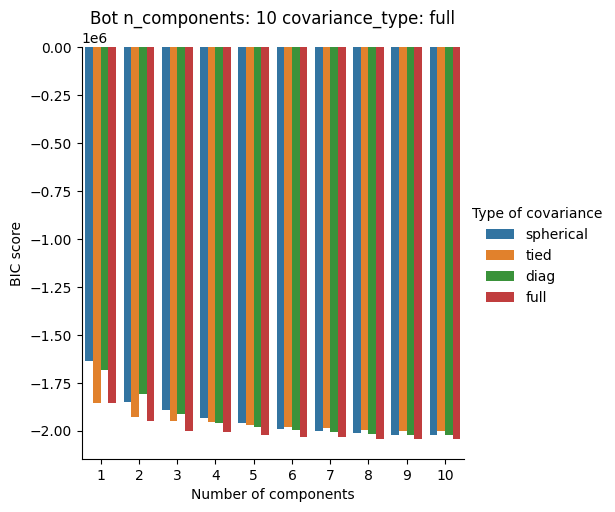

Tipo: 5 = Web
Melhor modelo: n_componentes: 7 covariance_type: full


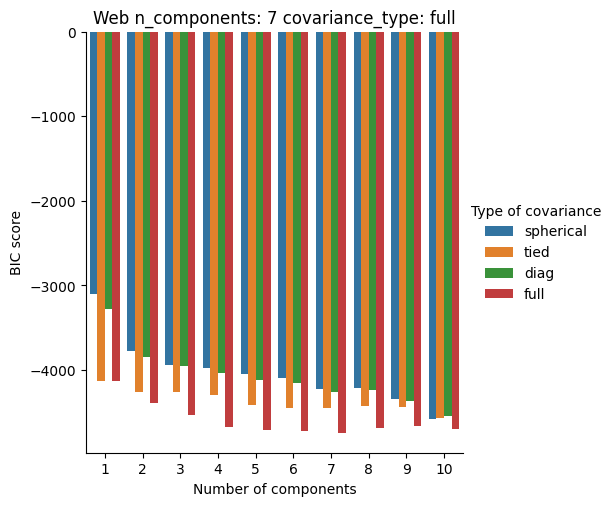

,0,1,2,3,4,5
0,NaN,28.330245,5.243628,-89.473577,18.109340,18.820144
1,NaN,11.290799,29.581183,-40.188382,7.180464,-40.656860
2,NaN,28.786990,6.256342,-84.877785,18.033485,18.618407
3,NaN,5.600193,-16.450650,29.342035,-35.763932,-135.102461
4,NaN,29.021951,8.067565,-73.354564,18.051136,18.626232
...,...,...,...,...,...,...
519951,NaN,28.152879,4.531371,-96.032025,18.258182,18.563551
519952,NaN,16.240991,-109.590075,-69.528794,28.839602,21.432268
519953,NaN,22.528741,11.689004,-33.459404,17.950513,16.979518
519954,NaN,28.941927,6.488596,-83.161525,18.241757,18.715500


,0,1,2,3,4,5
0,NaN,22.518036,11.774244,-33.312024,17.957582,16.960187
1,NaN,28.233245,4.906616,-91.733995,18.161083,18.809645
2,NaN,28.516167,8.111147,-76.302843,17.718267,17.638648
3,NaN,25.324199,12.196149,-45.908626,17.571482,17.907207
4,NaN,13.782078,13.578656,7.972309,7.501904,-2.499237
...,...,...,...,...,...,...
649942,NaN,29.058801,7.716967,-75.640283,18.092393,18.636971
649943,NaN,13.525982,11.896726,11.721466,5.390042,-7.973759
649944,NaN,13.610431,12.313639,11.088948,6.092062,-6.265335
649945,NaN,6.329271,-13.834306,29.199781,-32.302993,-123.935657


2


Label
0    808919
1    514148
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: diag


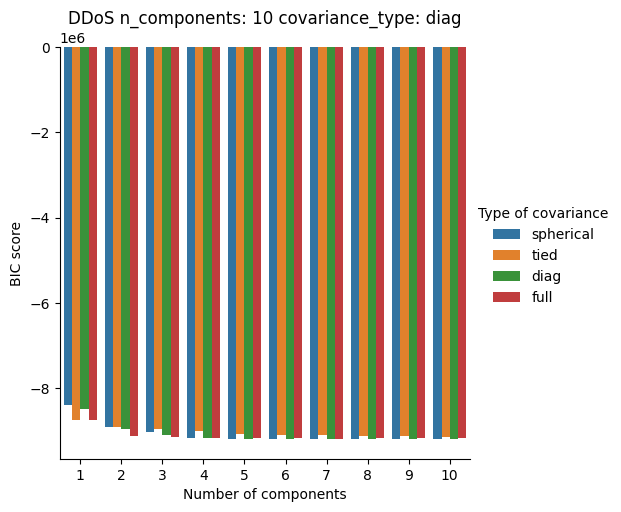

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


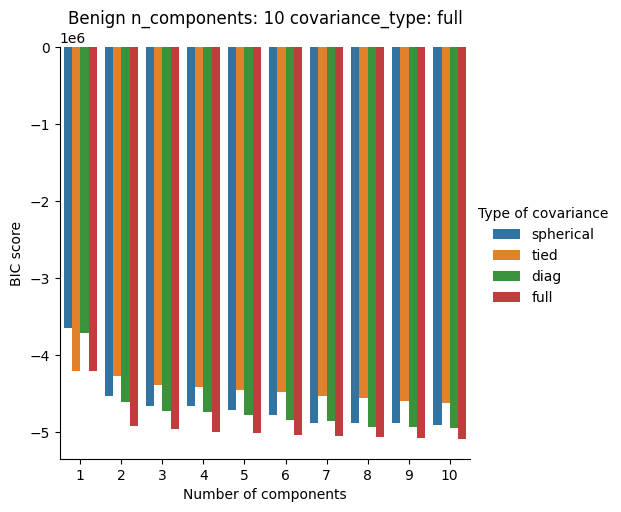

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 7 covariance_type: full


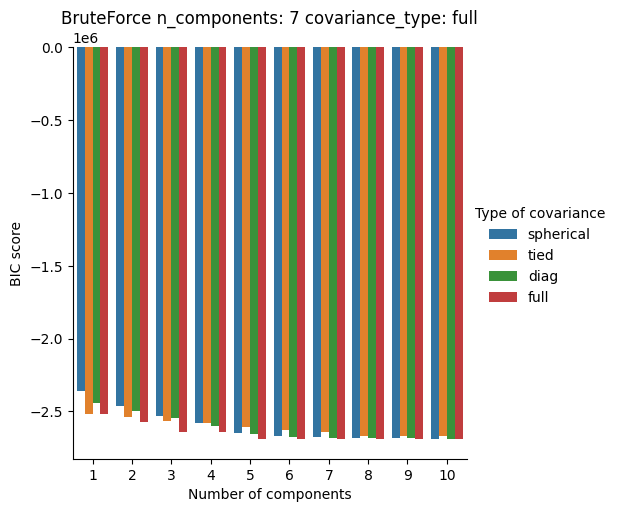

Tipo: 4 = Bot
Melhor modelo: n_componentes: 9 covariance_type: full


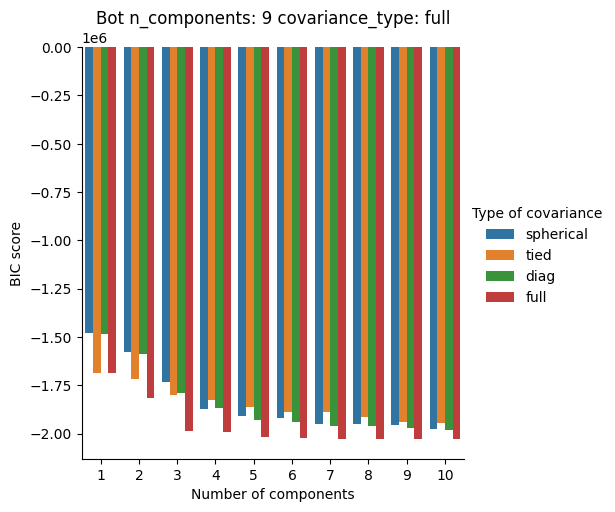

Tipo: 5 = Web
Melhor modelo: n_componentes: 8 covariance_type: full


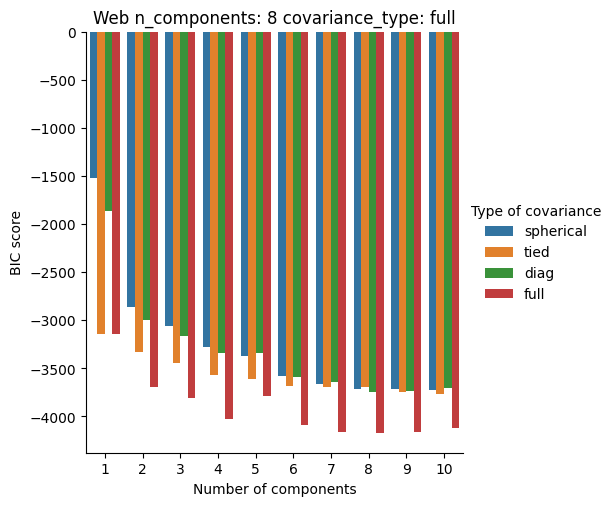

,0,1,2,3,4,5
0,28.194059,15.136755,NaN,-443.706479,5.801835,0.541173
1,-189.312770,11.910330,NaN,-77.258079,4.914244,1.457449
2,-69.835775,26.014323,NaN,-131.479368,11.401886,-3.058151
3,-244.987793,6.742576,NaN,27.725583,-104.383003,-120.932268
4,-46.121635,27.591375,NaN,-154.319495,11.931349,10.895540
...,...,...,...,...,...,...
519951,-66.777107,25.592481,NaN,-145.757801,11.961255,6.117558
519952,-315.327802,5.291685,NaN,-265.045911,29.108683,-2.176937
519953,28.995744,14.787916,NaN,-468.918999,5.960495,-8.444054
519954,-51.855411,26.391986,NaN,-155.293028,11.925702,10.592937


,0,1,2,3,4,5
0,28.969629,14.664211,NaN,-467.955968,6.043668,-8.549486
1,28.148396,15.136493,NaN,-443.127938,5.897375,1.001281
2,-39.037425,21.619807,NaN,-138.949080,11.398574,3.778834
3,-128.414563,17.632409,NaN,-170.595858,10.643961,-6.986302
4,28.686596,14.796576,NaN,-460.793555,5.628837,-4.664473
...,...,...,...,...,...,...
649942,-46.233561,27.714252,NaN,-152.901456,11.952755,10.518727
649943,28.543716,14.775790,NaN,-455.732504,5.837081,-3.074328
649944,28.796846,14.728512,NaN,-462.186594,5.706943,-3.440560
649945,-230.819025,7.149186,NaN,26.943799,-96.917345,-113.996327


3


Label
0    808919
1    514148
2    329224
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


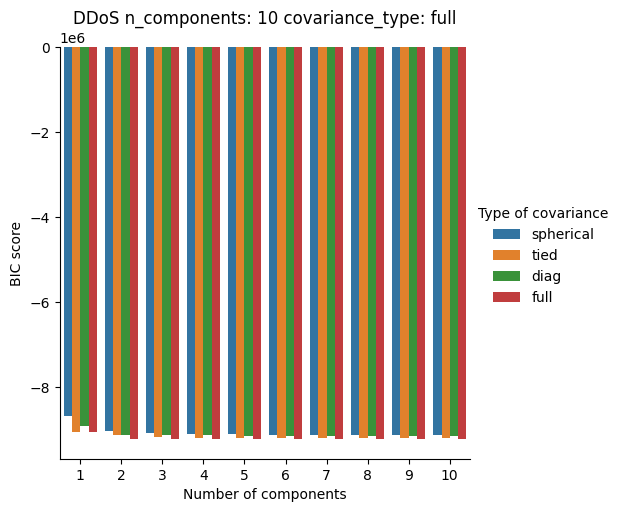

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


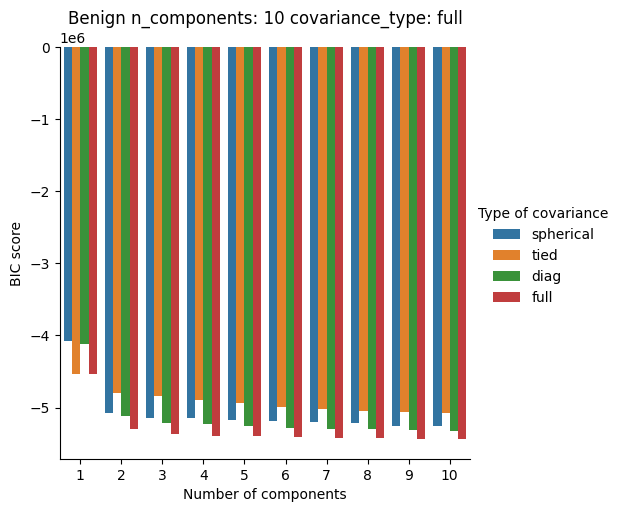

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


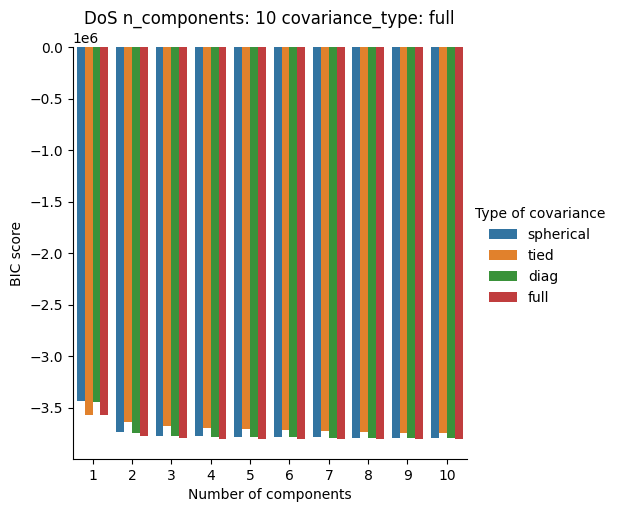

Tipo: 4 = Bot
Melhor modelo: n_componentes: 9 covariance_type: full


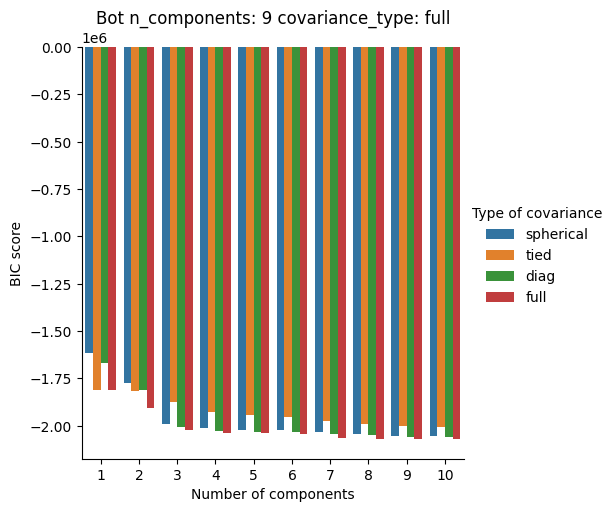

Tipo: 5 = Web
Melhor modelo: n_componentes: 6 covariance_type: full


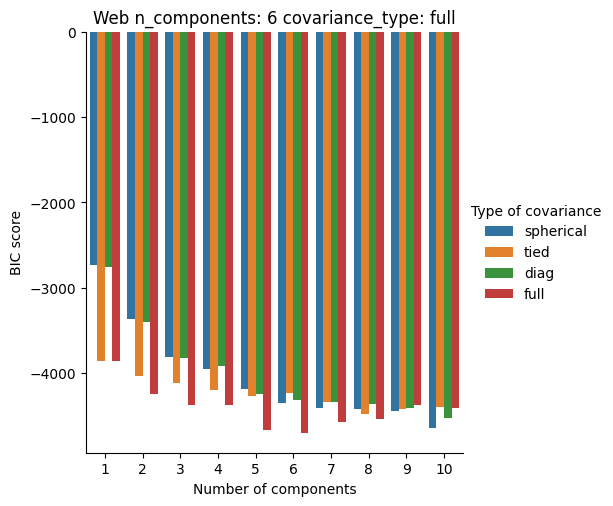

,0,1,2,3,4,5
0,28.537288,12.935367,-19.943014,NaN,10.318501,17.428748
1,-86.636694,14.908017,29.705473,NaN,-315.437514,-85.975192
2,6.569172,27.865855,-0.485905,NaN,16.418075,17.445675
3,-81.954721,15.676979,25.287271,NaN,-337.701825,-72.526807
4,8.678607,28.039922,1.547676,NaN,15.517171,17.441801
...,...,...,...,...,...,...
519951,8.322391,28.060638,1.214785,NaN,15.203014,17.527406
519952,-7.474611,15.278866,-92.964891,NaN,29.166266,6.638845
519953,29.029937,16.284248,-18.684706,NaN,8.979693,17.247974
519954,6.910773,27.125911,-0.264105,NaN,15.944100,16.786324


,0,1,2,3,4,5
0,29.043123,16.278597,-18.327724,NaN,9.106657,17.264843
1,28.588454,13.365978,-20.361603,NaN,9.915654,17.381896
2,5.542570,27.558656,-1.775895,NaN,16.241559,17.865883
3,-13.009323,20.449983,-23.665360,NaN,16.548400,17.955527
4,27.856706,12.268433,-20.017301,NaN,9.181457,17.382418
...,...,...,...,...,...,...
649942,8.357227,28.067749,1.349293,NaN,15.451249,17.436038
649943,28.874621,13.745298,-17.867386,NaN,9.801469,17.384131
649944,28.631397,12.486891,-19.882808,NaN,9.060739,17.332502
649945,-78.103973,-7.155675,-83.363479,NaN,-51.458046,-36.563647


4


Label
0    808919
1    514148
2    329224
3    243806
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


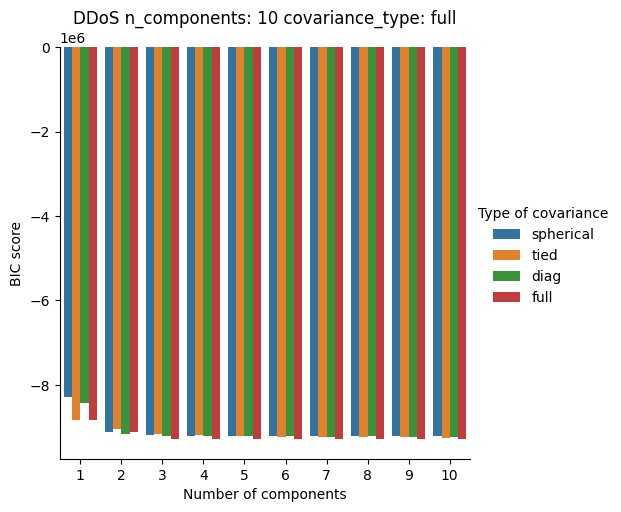

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


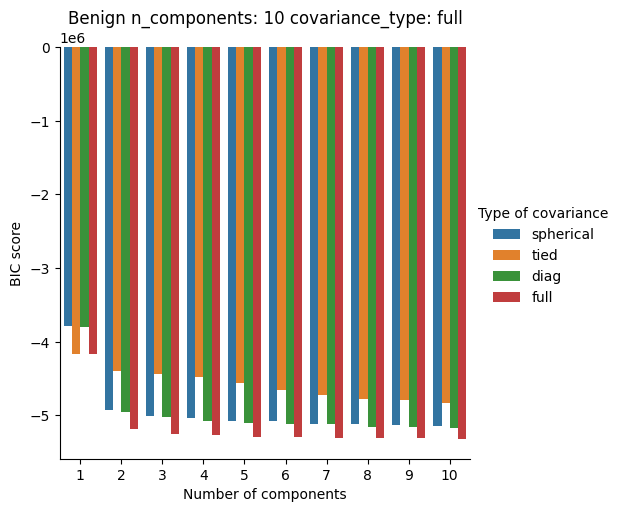

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


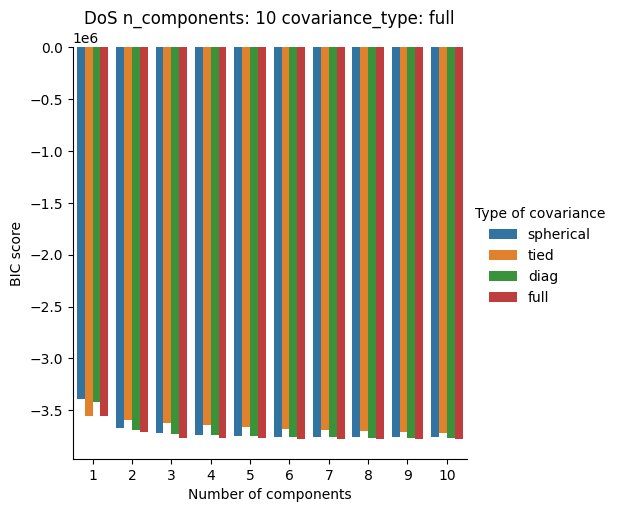

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 2 covariance_type: full


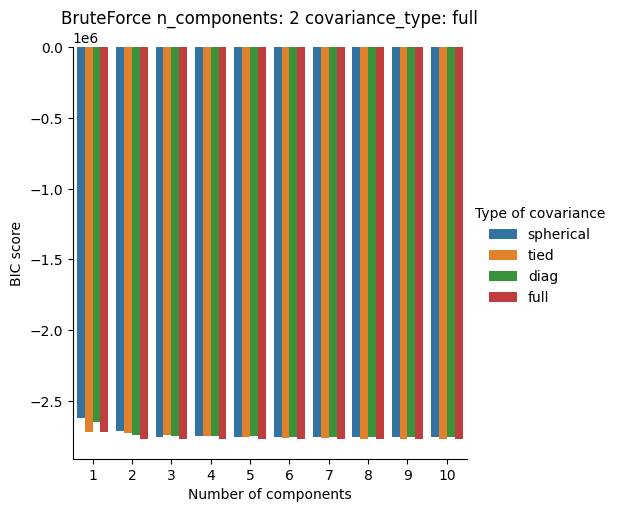

Tipo: 5 = Web
Melhor modelo: n_componentes: 9 covariance_type: spherical


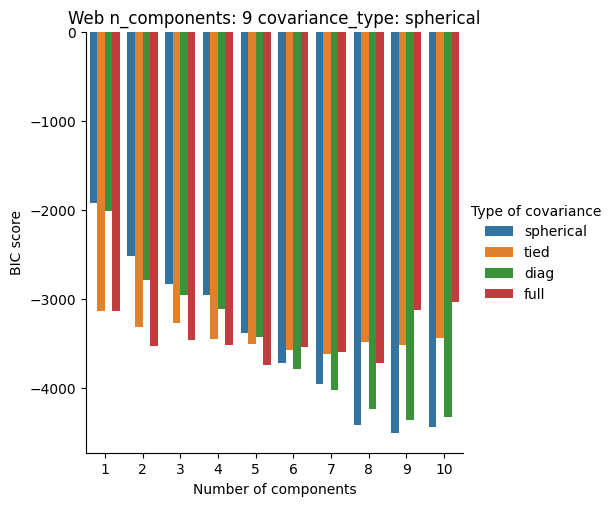

,0,1,2,3,4,5
0,29.096287,17.036432,-10.532893,-1037.356280,NaN,7.118751
1,-996.078400,-0.610895,29.519488,-57.863534,NaN,5.892621
2,-1.118962,27.262467,-17.711676,-837.688347,NaN,9.611356
3,-696.545964,-13.594632,-101.591526,28.618401,NaN,5.401257
4,6.307616,27.942634,-16.260512,-777.579065,NaN,9.590965
...,...,...,...,...,...,...
519951,3.378732,26.660062,-20.223284,-868.267832,NaN,9.624056
519952,-32.740217,21.639038,-9.323845,-682.149072,NaN,9.567077
519953,29.203600,19.707886,-8.001676,-1042.582655,NaN,7.158676
519954,9.157589,27.818000,-16.946327,-792.274966,NaN,9.586455


,0,1,2,3,4,5
0,29.194021,19.731955,-8.019699,-1041.670287,NaN,7.164388
1,29.048249,16.822927,-10.611194,-1033.291922,NaN,7.125323
2,-31.365882,18.664229,3.194841,-500.553781,NaN,9.312891
3,-2.406792,16.553944,1.387042,-435.669480,NaN,8.886907
4,28.014092,15.246861,-11.021842,-969.281546,NaN,7.218584
...,...,...,...,...,...,...
649942,4.510094,27.929800,-17.129712,-795.952847,NaN,9.600460
649943,28.191654,16.573070,-11.211559,-974.633200,NaN,7.236606
649944,28.338476,16.109984,-11.337317,-979.021164,NaN,7.215238
649945,-738.403395,-15.270269,-105.535979,28.586447,NaN,5.214068


5


Label
0    808919
1    514148
2    329224
3    243806
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


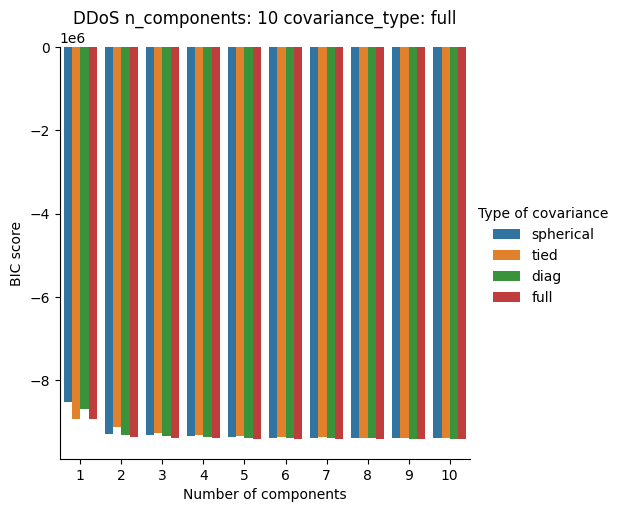

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


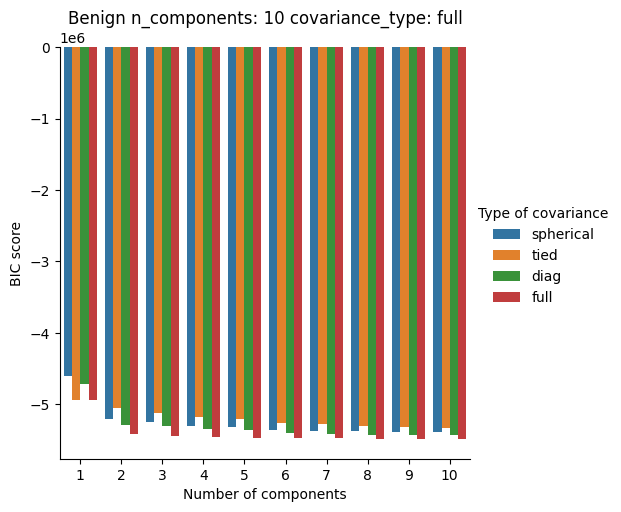

Tipo: 2 = DoS
Melhor modelo: n_componentes: 9 covariance_type: full


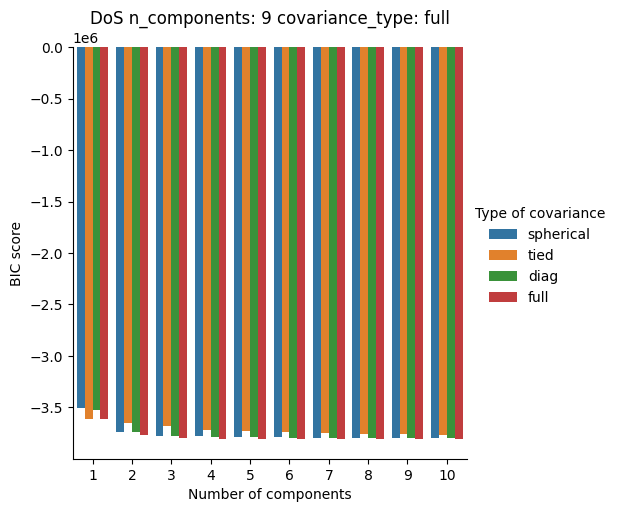

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 8 covariance_type: full


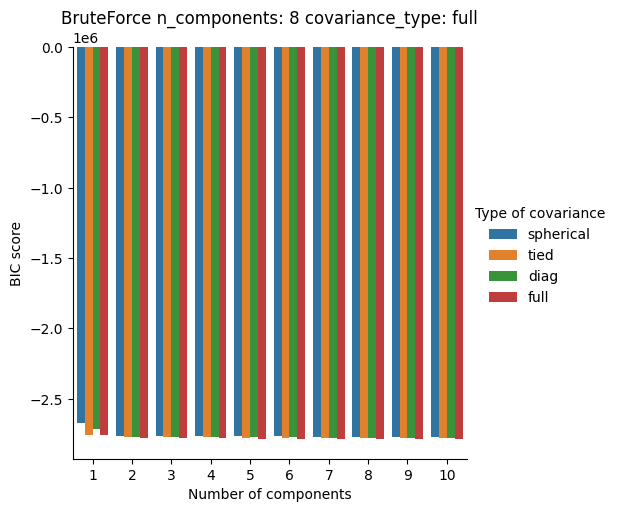

Tipo: 4 = Bot
Melhor modelo: n_componentes: 8 covariance_type: full


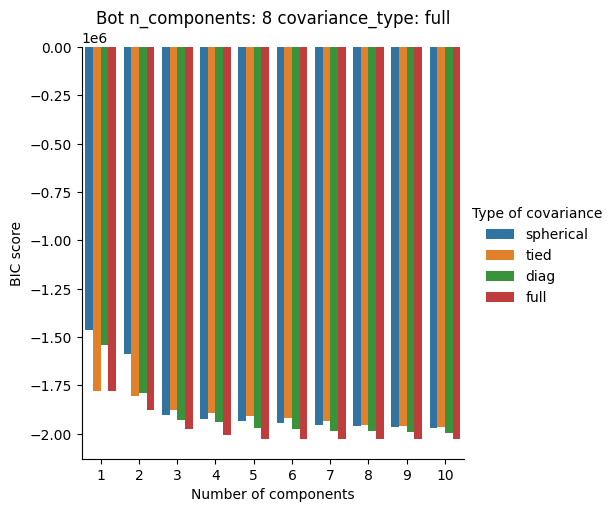

,0,1,2,3,4,5
0,29.458228,8.672432,-82.960904,-383.880452,11.919004,NaN
1,-782.654675,11.043500,29.590666,-2.361812,-176.770961,NaN
2,-39.409483,28.077127,7.001298,-844.506936,15.706625,NaN
3,-208.835438,6.715045,-46.350027,28.706363,-384.833475,NaN
4,-41.834876,28.244460,5.213708,-881.071821,16.108615,NaN
...,...,...,...,...,...,...
519951,-43.116872,27.895819,6.465599,-849.661649,15.398956,NaN
519952,-227.429868,11.228200,-279.099897,-1234.169081,28.807840,NaN
519953,29.538198,8.801229,-81.104934,-390.127219,11.854959,NaN
519954,-37.847514,28.001942,4.409416,-856.622137,15.950398,NaN


,0,1,2,3,4,5
0,29.560421,8.800666,-79.976866,-393.004718,11.829910,NaN
1,29.481668,8.656847,-83.321108,-383.801405,11.913360,NaN
2,-38.930282,27.002327,8.556803,-861.047761,16.102365,NaN
3,-91.714249,18.984990,3.059023,-840.063533,2.639848,NaN
4,29.180806,8.678704,-82.395628,-381.442302,11.946998,NaN
...,...,...,...,...,...,...
649942,-42.272701,28.263183,5.525189,-881.525965,16.088794,NaN
649943,29.299793,8.675743,-81.017848,-380.185885,11.855010,NaN
649944,29.334803,8.679402,-81.476583,-383.132870,11.903240,NaN
649945,-199.552943,7.010425,-40.056948,28.821269,-366.634860,NaN


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_val = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_val = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_val.append(val_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
            # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
        else:
            gmms.append(None)
    
    # scores = []
    # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
    #     max_dist = -np.inf
    #     pred = -1
    #     scores.append([])
    #     for j in range(len(labels_str)):
    #         if j not in hidden_classes:
    #             inside = False
    #             max = -np.inf
    #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
    #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
    #             scores[i].append(score)
    #         else:
    #             scores[i].append(np.nan)
    
    
    # display(pd.DataFrame(scores))
    # exp_train.append(scores)
    #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = val_encoded_df["Label"].values
    scores_df.to_csv(f'val_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)

    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)